# ASVspoof 原始與裁切後的音訊長度分布

本 notebook 使用 `data_utils_rhythm.py` 的既有流程，實際讀取 **ASVspoof 2019 LA（目標 4 秒）**與 **ASVspoof 5（目標 4 秒、10 秒）**，以 Matplotlib 繪製原始與裁切後的長度直方圖。每組為 **2×4，共 8 個子圖**：上排是原始音訊，下排是裁切後；由左至右為 **Train、Dev、Eval、All splits**。預設涵蓋各資料集原生 protocol 的 train、dev、eval；包含 bonafide 與 spoof。

## 統計定義

- **原始長度（秒）**：直接用 `data_utils_rhythm.load_audio()` 讀完整音檔，再以 `wav.numel() / SAMPLING_RATE` 計算，不裁切也不補零。上下排依 utterance ID 對齊，使用該目標下相同的有效樣本。原始分布因此不包含先前已被排除的音檔。

- `load_utt_spk_label()`：取得 protocol 中的 utterance ID。
- `load_duration_csv()`：讀取 rhythm 記錄，沿用現有驗證與排除規則。
- `load_rhythm_audio()`：內部呼叫 `select_duration()` 選取詞語停頓邊界，再用 `load_audio()` 解碼／重採樣音訊，回傳音訊及有效 sample 範圍 `(left, right)`。
- **真實長度（秒）＝ `(right - left) / SAMPLING_RATE`**。短音訊的置中補零與 batch padding 都不算入。原音檔中的自然停頓仍算入，這裡不是 VAD 的純發聲時間。
- 4 秒／10 秒是裁切的**目標**；為保留完整詞語，實際片段可能短於或長於目標。因此不以 `min(原長度, 目標秒數)` 估算，也不將補零後的 `wav.numel()` 當成真實長度。
- 每筆音檔、每個目標長度實際裁切一次；以 seed 與 utterance ID 固定亂數，不受執行緒數、資料順序或 4／10 秒執行順序影響。這是一輪可重現的裁切分布，不是所有 epoch 或所有可能裁切位置的分布。

缺少／無效 rhythm、音檔讀取失敗或裁切後沒有完整音節的樣本，會記錄在排除表並從直方圖排除。這裡只驗證音訊與 rhythm，不執行 speaker embedding 或 prosody teacher。


## 1. 環境與資料路徑

請選用專案 `.venv/bin/python` 對應的 Jupyter kernel，從本 notebook 所在的專案目錄執行。使用專案既有套件與本機音檔，不需載入模型權重。

以下 `RHYTHM_LEVELS = ("syllable",)` 與目前 `train_rhythm.sh` 相同；若要比較其他 rhythm 層級，可修改此參數後重新執行。它會影響 CSV 有效樣本的判定。

`MAX_UTTERANCES = None` 代表完整統計。若改為整數，只讀每個 split 的前 N 筆作試跑，並會在 `selected_count` 揭露，不能視為全資料集結果。`REUSE_SAVED_RESULTS = True` 會在 seed、資料路徑、資料範圍及 rhythm loader 原始碼一致時沿用已保存的裁切統計；若缺少原始長度，只會補讀完整音訊。同一音檔在 ASVspoof 5 的 4 秒與 10 秒版本只需補讀一次。

若音檔、protocol 或 rhythm CSV 的內容已有更新，請將 `REUSE_SAVED_RESULTS = False` 後重新執行，重新讀取所有資料。


In [1]:
%matplotlib inline

In [2]:
import hashlib
import json
import random
import sys
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from pathlib import Path

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "data_utils_rhythm.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm import tqdm

from data_utils_rhythm import (
    SAMPLING_RATE, load_audio, load_duration_csv, load_rhythm_audio, load_utt_spk_label,
)

# 多個音檔並行解碼時，避免每個 PyTorch 作業再開大量執行緒。
torch.set_num_threads(1)


/home/icebird/01_proj/ProSDD/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 1234
REUSE_SAVED_RESULTS = True
SPLITS = ("train", "dev", "eval")
MAX_UTTERANCES = None  # None 表示使用每個 split 的完整 protocol；可改為 1000 快速試跑。
WORKERS = 8
BIN_WIDTH = 0.1
RHYTHM_LEVELS = ("syllable",)  # 與目前 train_rhythm.sh 一致；也可加入 vowel、consonant。
OUTPUT_DIR = ROOT / "output" / "rhythm_crop_lengths"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

base19 = ROOT / "dataset" / "ASVspoof2019"
base5 = ROOT / "dataset" / "ASVspoof5"
DATASETS = {
    "ASVspoof 2019 LA": {
        split: {
            "protocol": base19 / "ASVspoof2019_LA_cm_protocols" / f"ASVspoof2019.LA.cm.{split}.{suffix}.txt",
            "wav_dir": base19 / f"ASVspoof2019_LA_{split}" / "flac",
            "duration_csv": base19 / "ASVspoof2019_LA_cache_csv" / f"cache_ASVspoof2019.LA_{split}.csv",
        }
        for split, suffix in (("train", "trn"), ("dev", "trl"), ("eval", "trl"))
    },
    "ASVspoof 5": {
        split: {
            "protocol": base5 / protocol,
            "wav_dir": base5 / folder,
            "duration_csv": base5 / "ASVspoof5_cache_csv" / f"cache_ASVspoof5_{split}.csv",
        }
        for split, protocol, folder in (
            ("train", "ASVspoof5.train.tsv", "flac_T"),
            ("dev", "ASVspoof5.dev.track_1.tsv", "flac_D"),
            ("eval", "ASVspoof5.eval.track_1.tsv", "flac_E_eval"),
        )
    },
}
SCAN_OPTIONS = dict(
    splits=SPLITS, seed=SEED, workers=WORKERS,
    max_utterances=MAX_UTTERANCES, rhythm_sources=RHYTHM_LEVELS,
)
run_config = {
    "seed": SEED, "splits": SPLITS, "max_utterances_per_split": MAX_UTTERANCES,
    "sample_rate": SAMPLING_RATE, "rhythm_sources": RHYTHM_LEVELS,
    "bin_width_sec": BIN_WIDTH,
    "targets_sec": {"ASVspoof 2019 LA": [4.0], "ASVspoof 5": [4.0, 10.0]},
    "data_utils_rhythm_sha256": hashlib.sha256((ROOT / "data_utils_rhythm.py").read_bytes()).hexdigest(),
    "paths": DATASETS,
}
run_config_path = OUTPUT_DIR / "run_config.json"
previous = json.loads(run_config_path.read_text()) if run_config_path.is_file() else {}
current = json.loads(json.dumps(run_config, default=str))
cache_keys = (
    "seed", "splits", "max_utterances_per_split", "sample_rate", "rhythm_sources",
    "targets_sec", "data_utils_rhythm_sha256", "paths",
)
CACHE_COMPATIBLE = REUSE_SAVED_RESULTS and all(previous.get(key) == current[key] for key in cache_keys)
if not CACHE_COMPATIBLE:
    run_config_path.unlink(missing_ok=True)  # 完成兩個資料集後才寫入新設定，避免重用中斷的結果。
print(f"取樣率：{SAMPLING_RATE:,} Hz；亂數種子：{SEED}；split：{', '.join(SPLITS)}")
print("統計範圍：完整 protocol" if MAX_UTTERANCES is None else f"試跑範圍：每個 split 前 {MAX_UTTERANCES:,} 筆")
print(f"結果輸出：{OUTPUT_DIR}")

print("沿用已保存的裁切統計，必要時補讀原始音訊。" if CACHE_COMPATIBLE else "重新實讀所有音訊並統計。")


取樣率：16,000 Hz；亂數種子：1234；split：train, dev, eval
統計範圍：完整 protocol
結果輸出：/home/icebird/01_proj/ProSDD/output/rhythm_crop_lengths
沿用已保存的裁切統計，必要時補讀原始音訊。


## 2. 共用統計與繪圖函式

兩個資料集使用相同函式。`original_sec` 是完整音訊的秒數，由 `load_audio()` 實讀而來；與 `actual_sec` 依同一個音檔對齊。ASVspoof 5 的 4 秒及 10 秒共用同一次 CSV 讀取，但每個目標都會各自透過 rhythm loader 真正裁切、解碼。

`actual_sec` 是下排圖表使用的裁切後真實秒數；`tensor_sec` 是 loader 回傳張量的秒數，僅供檢查補零差異。每個目標都滿足 `selected_count = valid_count + skipped_count`。`protocol_count` 表示原始 protocol 筆數。


In [4]:
def measure_crops(utt_id, record, *, wav_dir, crop_seconds, seed):
    """用 rhythm loader 實讀單筆音訊；輸入 ID、CSV 記錄及目標秒數，輸出長度列與失敗列。"""
    rows, failures = [], []
    for target in crop_seconds:
        try:
            wav, _, (left, right) = load_rhythm_audio(
                Path(wav_dir) / f"{utt_id}.flac", record,
                max_len=target, sr=SAMPLING_RATE,
                rng=random.Random(f"{seed}:{utt_id}"),
            )
            rows.append({
                "utt_id": utt_id,
                "target_sec": float(target),
                "valid_samples": right - left,
                "tensor_samples": wav.numel(),
                "actual_sec": (right - left) / SAMPLING_RATE,
                "tensor_sec": wav.numel() / SAMPLING_RATE,
            })
        except (OSError, RuntimeError, ValueError) as exc:
            failures.append({
                "utt_id": utt_id, "target_sec": float(target),
                "stage": "audio_crop", "reason": str(exc),
            })
    return rows, failures


def original_length(path):
    """以 rhythm 的 load_audio 實讀完整音檔；輸入音檔路徑，輸出未裁切／未補零的秒數。"""
    return load_audio(path, target_sr=SAMPLING_RATE).numel() / SAMPLING_RATE


def add_original_lengths(lengths, specs, *, workers=8, progress=True):
    """補讀各音檔原始長度，依 split／ID 對齊裁切結果；輸入長度表及音檔路徑，輸出 original_sec 欄位。"""
    if "original_sec" in lengths:
        return lengths
    parts = []
    unique = lengths[["split", "utt_id"]].drop_duplicates()
    for split, items in unique.groupby("split", sort=False):
        ids = items["utt_id"].tolist()
        wav_dir = Path(specs[split]["wav_dir"])
        seconds = []
        with ThreadPoolExecutor(max_workers=workers) as pool, tqdm(
            total=len(ids), desc=f"Original / {split}", unit="file",
            disable=not progress, mininterval=15, leave=False,
        ) as bar:
            for offset in range(0, len(ids), 1024):
                batch = ids[offset:offset + 1024]
                paths = (wav_dir / f"{utt}.flac" for utt in batch)
                seconds.extend(pool.map(original_length, paths))
                bar.update(len(batch))
        parts.append(items.assign(original_sec=seconds))
    originals = pd.concat(parts, ignore_index=True)
    return lengths.merge(originals, on=["split", "utt_id"], how="left", validate="many_to_one")


In [5]:
def collect_split(protocol, wav_dir, duration_csv, crop_seconds, *,
                  seed=1234, workers=8, max_utterances=None,
                  rhythm_sources=("syllable",), progress=True):
    """實讀一個 split；輸入 protocol、音檔／CSV 路徑與目標秒數，輸出長度、失敗紀錄及計數表。"""
    wav_dir = Path(wav_dir)
    if not wav_dir.is_dir():
        raise FileNotFoundError(f"Audio directory does not exist: {wav_dir}")
    utt_ids, _, _ = load_utt_spk_label(str(protocol))
    protocol_count = len(utt_ids)
    if max_utterances is not None:
        utt_ids = utt_ids[:max_utterances]
    records, invalid = load_duration_csv(duration_csv, utt_ids, rhythm_sources)
    failures = [
        {"utt_id": utt, "target_sec": float(target), "stage": "duration_csv", "reason": reason}
        for utt, reason in invalid.items() for target in crop_seconds
    ]
    valid_ids = [utt for utt in utt_ids if utt in records]
    rows = []
    measure = partial(measure_crops, wav_dir=wav_dir, crop_seconds=crop_seconds, seed=seed)
    with ThreadPoolExecutor(max_workers=workers) as pool, tqdm(
        total=len(valid_ids), desc=Path(protocol).name, unit="file",
        disable=not progress, mininterval=15, leave=False,
    ) as bar:
        # 分批送入工作佇列，避免一次建立數十萬個 Future。
        for offset in range(0, len(valid_ids), 1024):
            batch = valid_ids[offset:offset + 1024]
            for result, errors in pool.map(measure, batch, (records[utt] for utt in batch)):
                rows.extend(result)
                failures.extend(errors)
                bar.update(1)
    lengths = pd.DataFrame(rows, columns=[
        "utt_id", "target_sec", "valid_samples", "tensor_samples", "actual_sec", "tensor_sec",
    ])
    errors = pd.DataFrame(failures, columns=["utt_id", "target_sec", "stage", "reason"])
    audit = pd.DataFrame([
        {
            "target_sec": float(target), "protocol_count": protocol_count,
            "selected_count": len(utt_ids),
            "valid_count": int(lengths["target_sec"].eq(target).sum()),
            "skipped_count": int(errors["target_sec"].eq(target).sum()),
        }
        for target in crop_seconds
    ])
    return lengths, errors, audit


In [6]:
def summarize_lengths(lengths):
    """彙整各目標／split 與全體的實際秒數、分位數及偏離目標的數量，回傳 DataFrame。"""
    data = lengths.assign(
        shorter=lengths["valid_samples"] < (lengths["target_sec"] * SAMPLING_RATE).round(),
        exact=lengths["valid_samples"] == (lengths["target_sec"] * SAMPLING_RATE).round(),
        longer=lengths["valid_samples"] > (lengths["target_sec"] * SAMPLING_RATE).round(),
    )
    data = pd.concat([data.assign(split="All"), data], ignore_index=True)
    return data.groupby(["dataset", "target_sec", "split"], sort=False).agg(
        count=("actual_sec", "size"),
        min_sec=("actual_sec", "min"),
        p05_sec=("actual_sec", lambda values: values.quantile(0.05)),
        mean_sec=("actual_sec", "mean"),
        median_sec=("actual_sec", "median"),
        p95_sec=("actual_sec", lambda values: values.quantile(0.95)),
        max_sec=("actual_sec", "max"),
        shorter_count=("shorter", "sum"),
        exact_count=("exact", "sum"),
        longer_count=("longer", "sum"),
    ).reset_index()


In [7]:
def collect_dataset(dataset, specs, crop_seconds, *, splits=("train", "dev", "eval"),
                    cache_prefix=None, **options):
    """依 split 實讀或載入已驗證設定的快取；輸入資料集／路徑，輸出長度、排除及母數三張表。"""
    if cache_prefix is not None:
        paths = [Path(f"{cache_prefix}_{suffix}")
                 for suffix in ("lengths.csv.gz", "skipped.csv", "coverage.csv")]
        if all(path.is_file() for path in paths):
            if options.get("progress", True):
                print(f"{dataset}：載入已保存且設定一致的裁切統計。", flush=True)
            return tuple(pd.read_csv(path) for path in paths)
    chunks = [[], [], []]
    for split in splits:
        if options.get("progress", True):
            print(f"{dataset} / {split}：讀取 rhythm CSV 並統計音訊。", flush=True)
        result = collect_split(**specs[split], crop_seconds=crop_seconds, **options)
        for bucket, frame in zip(chunks, result):
            bucket.append(frame.assign(dataset=dataset, split=split))
    return tuple(pd.concat(bucket, ignore_index=True) for bucket in chunks)


def save_results(stem, output_dir, lengths, errors, audit):
    """保存逐檔秒數、排除原因、母數與摘要表；輸入三張統計表，回傳摘要 DataFrame。"""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    summary = summarize_lengths(lengths)
    lengths.to_csv(output_dir / f"{stem}_lengths.csv.gz", index=False, compression="gzip")
    errors.to_csv(output_dir / f"{stem}_skipped.csv", index=False)
    audit.to_csv(output_dir / f"{stem}_coverage.csv", index=False)
    summary.to_csv(output_dir / f"{stem}_summary.csv", index=False)
    return summary


In [8]:
def plot_lengths(lengths, *, dataset, target_sec, bin_width=0.1):
    """繪製 2×4 英文直方圖；輸入含 original_sec 的逐檔長度表，輸出原始／裁切後分布 Figure。"""
    selected = lengths.loc[
        lengths["dataset"].eq(dataset) & lengths["target_sec"].eq(target_sec)
    ]
    if selected.empty:
        raise ValueError(f"No valid audio for {dataset}, target={target_sec:g} s")
    upper = max(target_sec, selected[["original_sec", "actual_sec"]].max().max())
    bins = np.arange(int(np.ceil(upper / bin_width)) + 1) * bin_width
    fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, layout="constrained")
    for col, (split, color) in enumerate(zip(
        ("train", "dev", "eval", "All"),
        ("#3f8b81", "#ca8b3f", "#8674ad", "#35618f"),
    )):
        data = selected if split == "All" else selected.loc[selected["split"].eq(split)]
        split_title = "All splits" if split == "All" else split.title()
        for row, (column, label) in enumerate((
            ("original_sec", "Original"), ("actual_sec", f"Cropped ({target_sec:g} s)"),
        )):
            ax = axes[row, col]
            values = data[column]
            ax.hist(values, bins=bins, color=color, alpha=0.7 if row == 0 else 1.0,
                    edgecolor="white", linewidth=0.25)
            ax.axvline(target_sec, color="#b84440", linestyle="--", linewidth=1.5,
                       label=f"Target: {target_sec:g} s")
            ax.set(title=f"{label} | {split_title}",
                   xlabel="Sample length (sec)", ylabel="Count", xlim=(0, bins[-1]))
            ax.tick_params(axis="x", labelbottom=True)
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
            ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
            ax.grid(axis="y", alpha=0.18)
            ax.set_axisbelow(True)
            ax.spines[["top", "right"]].set_visible(False)
            ax.legend(loc="upper left", frameon=False, fontsize=9)
            note = (
                f"N = {len(values):,}\nMean = {values.mean():.3f} s\n"
                f"Median = {values.median():.3f} s\n"
                f"Range = {values.min():.3f} - {values.max():.3f} s"
            ) if len(values) else "No valid samples"
            ax.text(0.97, 0.95, note, transform=ax.transAxes, ha="right", va="top",
                    fontsize=9, bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none"})
    fig.suptitle(
        f"{dataset} | Original vs cropped audio | Target crop: {target_sec:g} s\n"
        f"Same utterances in both rows | Padding excluded | Bin width: {bin_width:g} s",
        fontsize=16,
    )
    return fig


## 3. ASVspoof 2019 LA：目標 4 秒

先顯示各 split 的成功／排除數量，再列出秒數摘要。`shorter_count`、`exact_count`、`longer_count` 分別表示有效 samples 少於、等於、多於目標 samples 的筆數。


In [9]:
lengths19, skipped19, coverage19 = collect_dataset(
    "ASVspoof 2019 LA", DATASETS["ASVspoof 2019 LA"], (4.0,), cache_prefix=OUTPUT_DIR / "asvspoof2019_la" if CACHE_COMPATIBLE else None,
    **SCAN_OPTIONS,
)
lengths19 = add_original_lengths(lengths19, DATASETS["ASVspoof 2019 LA"], workers=WORKERS)
summary19 = save_results("asvspoof2019_la", OUTPUT_DIR, lengths19, skipped19, coverage19)
display(coverage19)
display(summary19.round(4))


ASVspoof 2019 LA：載入已保存且設定一致的裁切統計。


,target_sec,protocol_count,selected_count,valid_count,skipped_count,dataset,split
0,4.0,25380,25380,25377,3,ASVspoof 2019 LA,train
1,4.0,24844,24844,24842,2,ASVspoof 2019 LA,dev
2,4.0,71237,71237,71226,11,ASVspoof 2019 LA,eval


,dataset,target_sec,split,count,min_sec,p05_sec,mean_sec,median_sec,p95_sec,max_sec,shorter_count,exact_count,longer_count
0,ASVspoof 2019 LA,4.0,All,121445,0.4699,1.3600,2.9972,2.9799,4.5801,10.3790,94537,10772,16136
1,ASVspoof 2019 LA,4.0,train,25377,0.5999,1.5975,3.1483,3.1926,4.5401,9.4140,19010,3256,3111
2,ASVspoof 2019 LA,4.0,dev,24842,0.6951,1.5324,3.1712,3.2530,4.5591,10.3790,18117,3463,3262
3,ASVspoof 2019 LA,4.0,eval,71226,0.4699,1.2697,2.8828,2.8108,4.6022,8.7001,57410,4053,9763


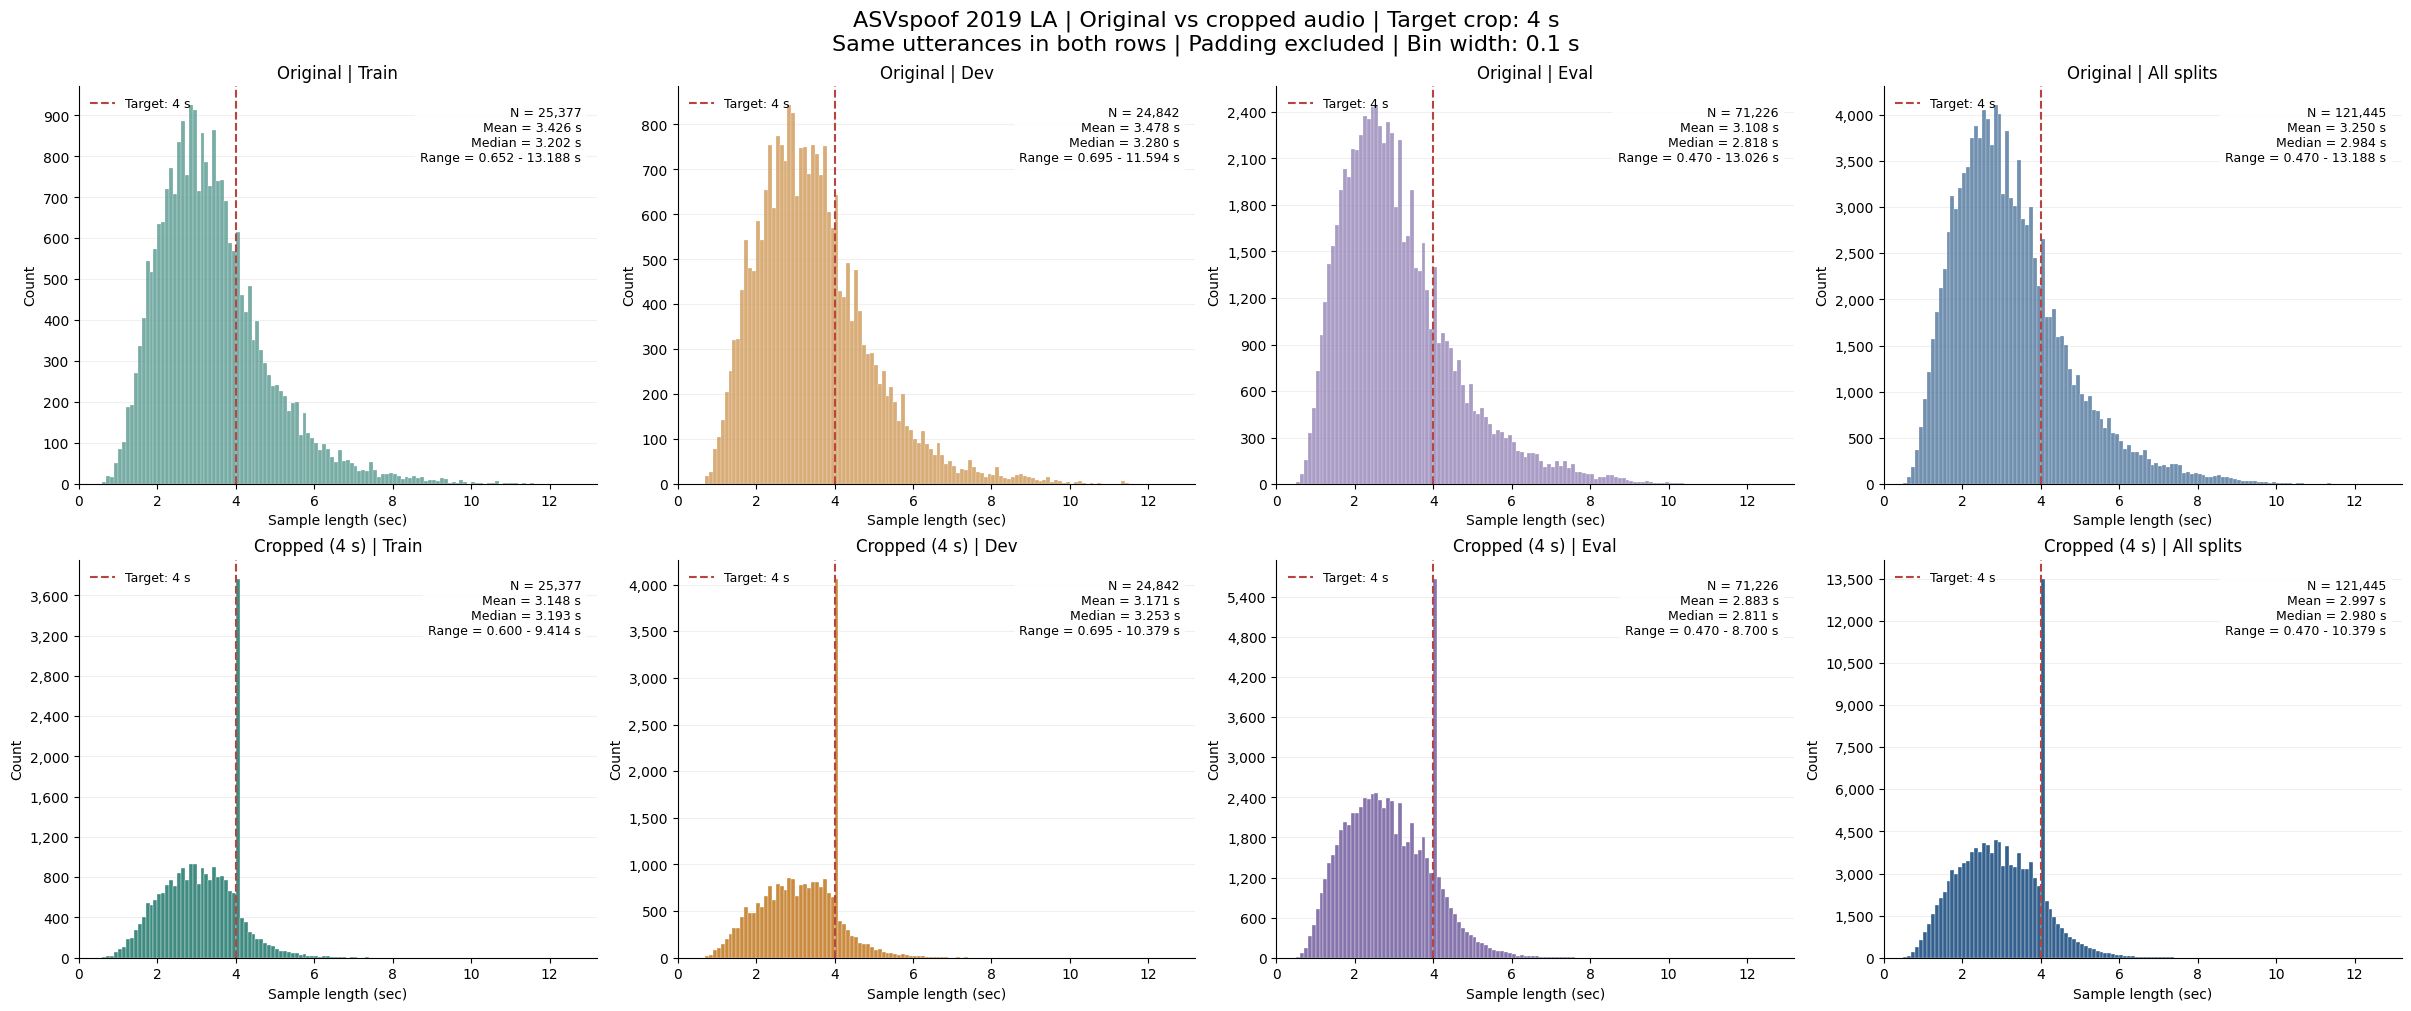

In [10]:
fig19 = plot_lengths(lengths19, dataset="ASVspoof 2019 LA", target_sec=4.0, bin_width=BIN_WIDTH)
fig19.savefig(OUTPUT_DIR / "asvspoof2019_la_crop_4s.png", dpi=160)
plt.show()


## 4. ASVspoof 5：目標 4 秒與 10 秒

以下一次統計兩個目標；每個目標各有一張 2×4 的圖，上排 Original、下排 Cropped，四欄依序為 Train、Dev、Eval、All splits。上下排使用相同音檔、相同分箱與 x 軸範圍；y 軸分別縮放以看清分布。兩個目標若有不同的有效樣本數，可由 `skipped5` 查詢原因。


In [11]:
lengths5, skipped5, coverage5 = collect_dataset(
    "ASVspoof 5", DATASETS["ASVspoof 5"], (4.0, 10.0), cache_prefix=OUTPUT_DIR / "asvspoof5" if CACHE_COMPATIBLE else None,
    **SCAN_OPTIONS,
)
lengths5 = add_original_lengths(lengths5, DATASETS["ASVspoof 5"], workers=WORKERS)
summary5 = save_results("asvspoof5", OUTPUT_DIR, lengths5, skipped5, coverage5)
display(coverage5)
display(summary5.round(4))


ASVspoof 5：載入已保存且設定一致的裁切統計。


,target_sec,protocol_count,selected_count,valid_count,skipped_count,dataset,split
0,4.0,182357,182357,182303,54,ASVspoof 5,train
1,10.0,182357,182357,182303,54,ASVspoof 5,train
2,4.0,140950,140950,127877,13073,ASVspoof 5,dev
3,10.0,140950,140950,127877,13073,ASVspoof 5,dev
4,4.0,680774,680774,641722,39052,ASVspoof 5,eval
5,10.0,680774,680774,641725,39049,ASVspoof 5,eval


,dataset,target_sec,split,count,min_sec,p05_sec,mean_sec,median_sec,p95_sec,max_sec,shorter_count,exact_count,longer_count
0,ASVspoof 5,4.0,All,951902,0.1200,2.8700,4.1976,4.1076,5.7001,17.7701,359958,41829,550115
1,ASVspoof 5,10.0,All,951905,0.1200,4.3504,7.5826,7.6938,10.4401,18.3001,837565,12230,102110
2,ASVspoof 5,4.0,train,182303,0.2000,2.5700,4.1152,4.0700,5.7501,14.8401,81708,3523,97072
3,ASVspoof 5,10.0,train,182303,2.6080,7.5200,9.7380,9.9494,11.3601,18.3001,95302,8297,78704
4,ASVspoof 5,4.0,dev,127877,0.1200,2.8895,4.2506,4.1369,5.8401,17.7701,43407,7589,76881
5,ASVspoof 5,10.0,dev,127877,0.1200,4.2750,7.0585,7.0450,9.7700,17.7701,125357,916,1604
6,ASVspoof 5,4.0,eval,641722,0.2615,2.9800,4.2104,4.1100,5.6600,14.9401,234843,30717,376162
7,ASVspoof 5,10.0,eval,641725,2.0038,4.2600,7.0747,7.0944,9.9062,16.4710,616906,3017,21802


### 4.1 目標 4 秒

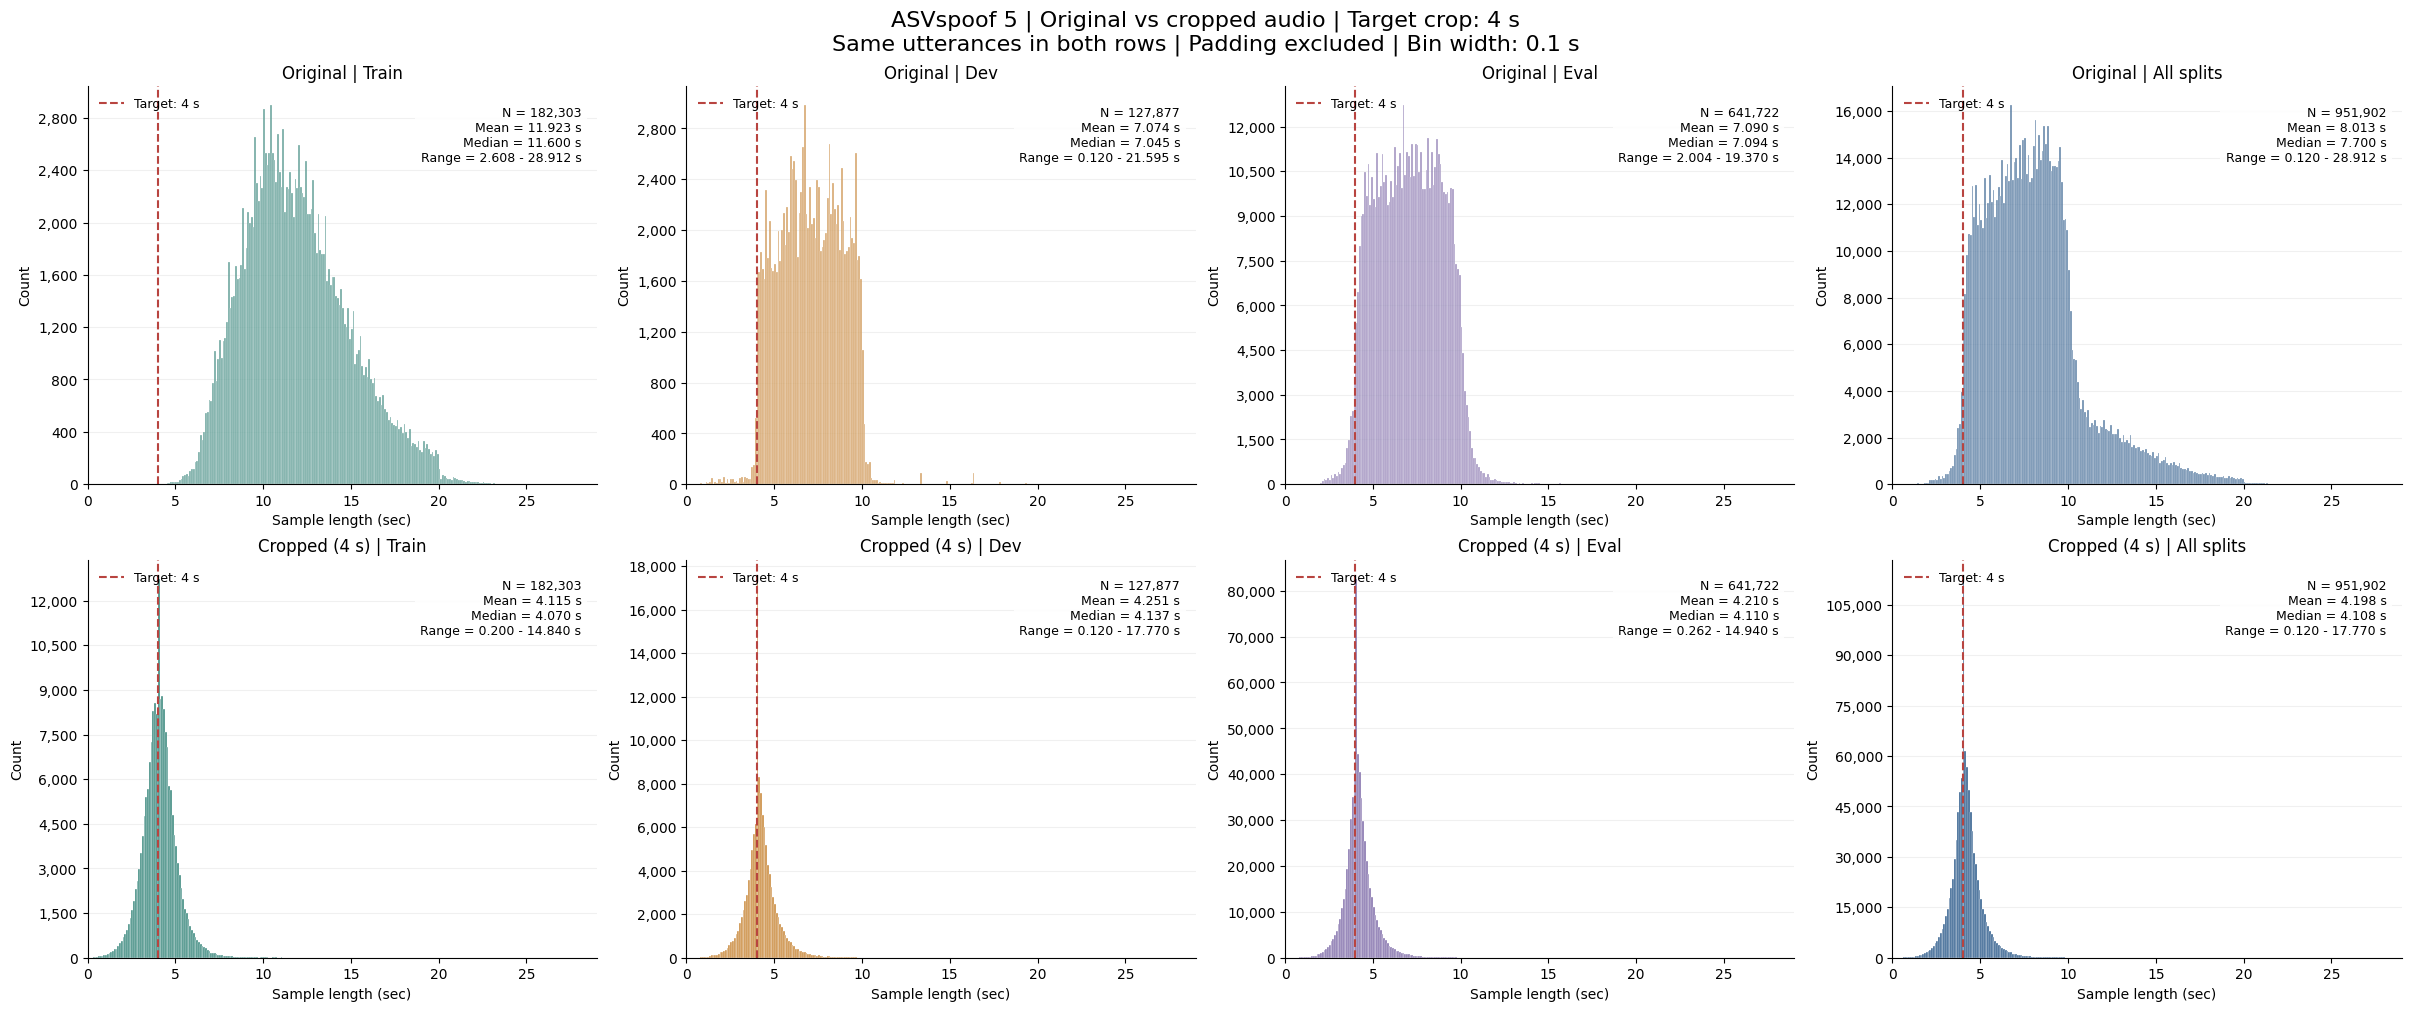

In [12]:
fig5_4 = plot_lengths(lengths5, dataset="ASVspoof 5", target_sec=4.0, bin_width=BIN_WIDTH)
fig5_4.savefig(OUTPUT_DIR / "asvspoof5_crop_4s.png", dpi=160)
plt.show()


### 4.2 目標 10 秒

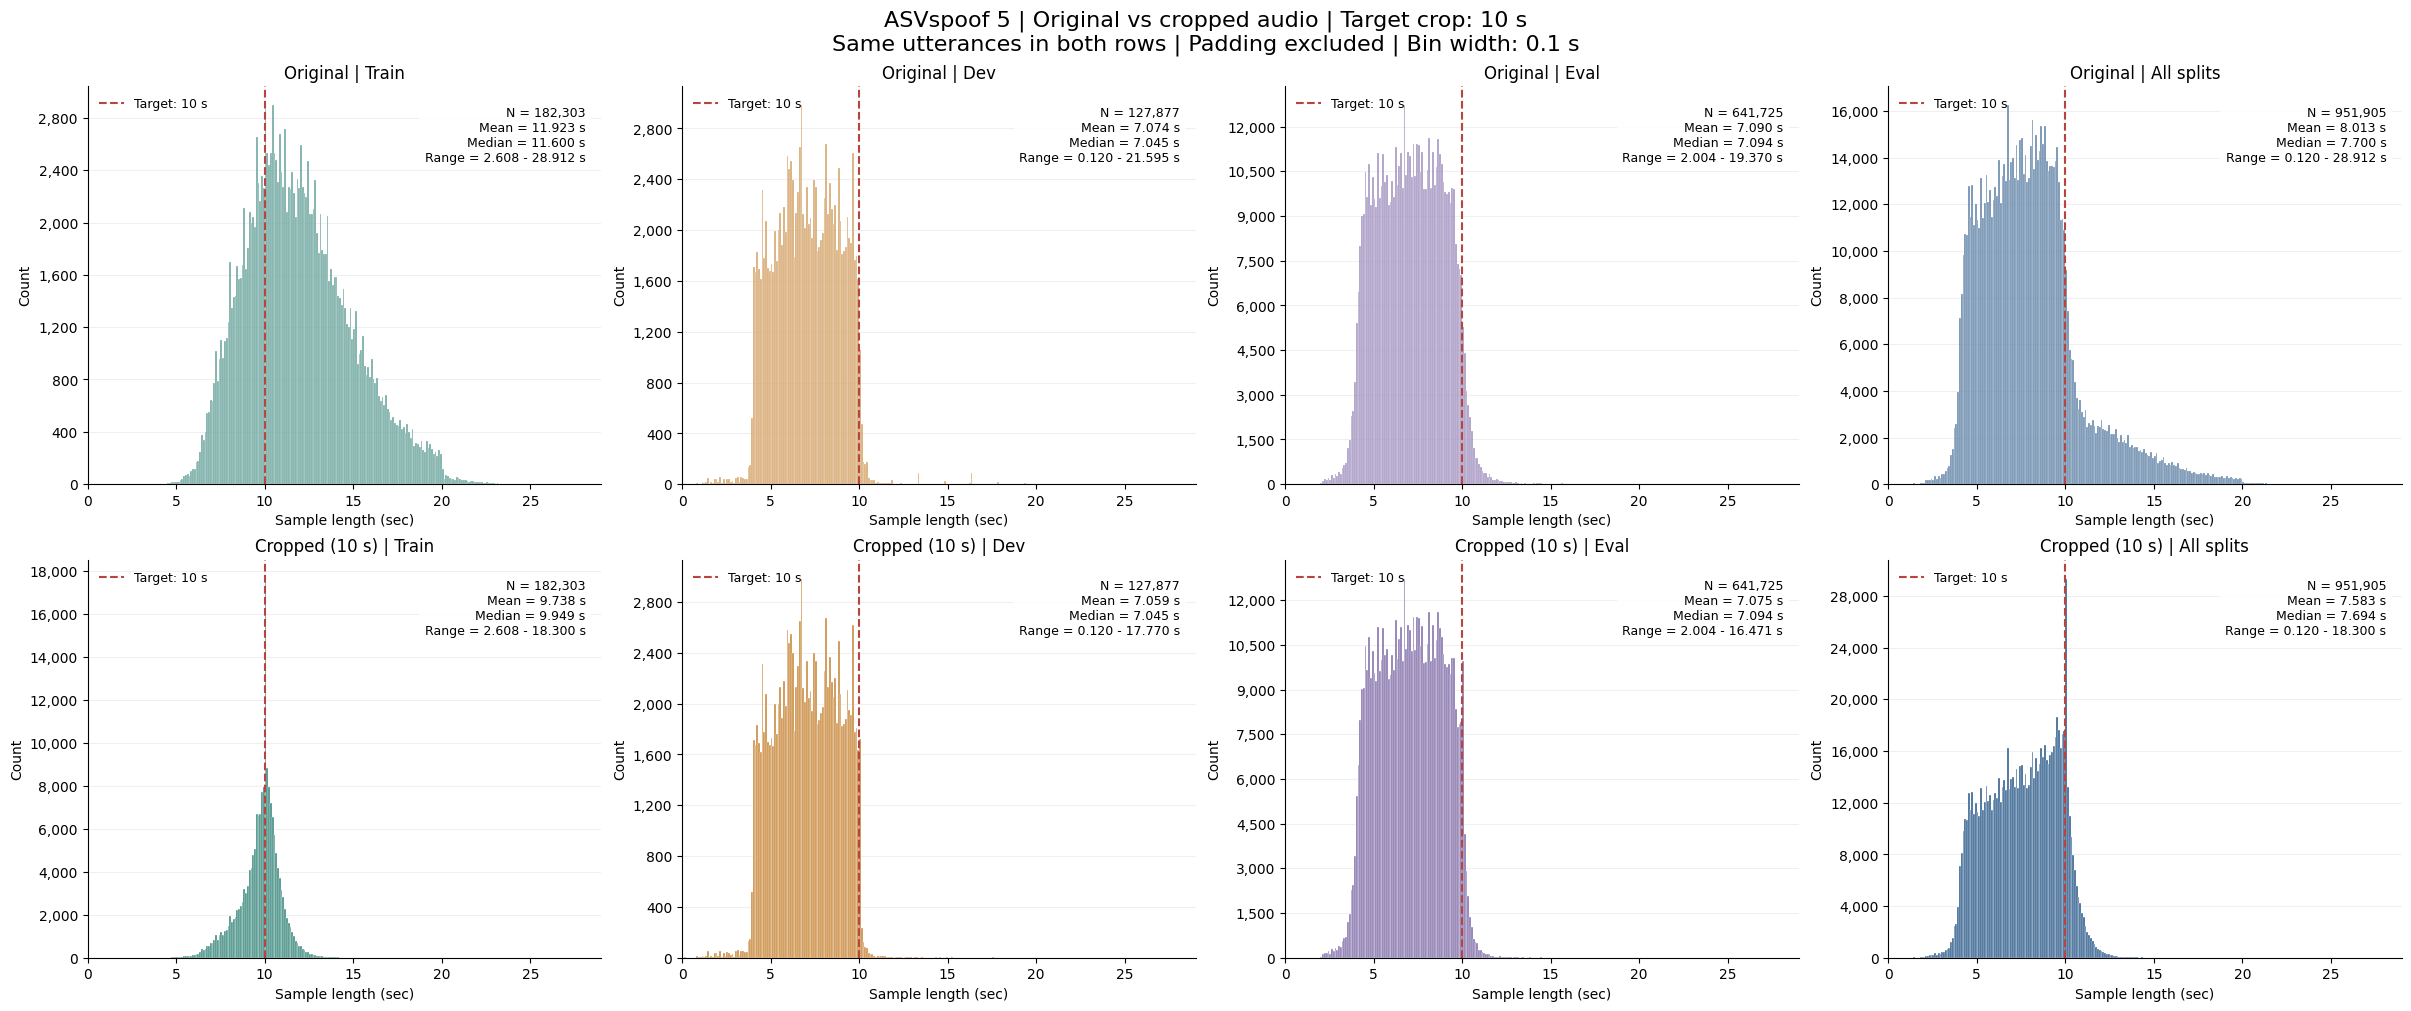

In [13]:
fig5_10 = plot_lengths(lengths5, dataset="ASVspoof 5", target_sec=10.0, bin_width=BIN_WIDTH)
fig5_10.savefig(OUTPUT_DIR / "asvspoof5_crop_10s.png", dpi=160)
plt.show()


## 5. 排除原因與結果檔案

下表按資料集、split、目標秒數與處理階段彙整排除數量。每個目標各記一筆，因此 ASVspoof 5 同一個無效音檔可能在 4 秒與 10 秒各出現一次。

輸出位於 `output/rhythm_crop_lengths/`：三張各含 8 個子圖的 PNG 圖、包含 `original_sec` 的逐檔長度 `.csv.gz`、排除原因 `_skipped.csv`、統計母數 `_coverage.csv`、秒數摘要 `_summary.csv` 與包含 seed／原始碼雜湊的 `run_config.json`。圖表也保存在本 notebook 的輸出中。

英文圖表的 x 軸為 **Sample length (sec)**、y 軸為 **Count**；每根柱子表示該長度區間的音檔數量，沒有轉成密度或百分比。紅色虛線為目標秒數，各圖的 x 軸涵蓋原始與裁切後的完整長度範圍。ASVspoof 5 兩種目標可能有少量不同的有效樣本，所以兩組原始分布的 N 也可能不同。


In [14]:
skipped = pd.concat([skipped19, skipped5], ignore_index=True)
if skipped.empty:
    print("所有選取的樣本皆成功讀取及裁切。")
else:
    display(skipped.groupby(["dataset", "split", "target_sec", "stage"], sort=False)
            .size().rename("skipped_count").reset_index())
    display(skipped.head(10))

all_summary = pd.concat([summary19, summary5], ignore_index=True)
display(all_summary.loc[all_summary["split"].eq("All")].round(4))
print(f"三張圖與完整統計已儲存至：{OUTPUT_DIR}")

run_config_path.write_text(json.dumps(run_config, indent=2, default=str), encoding="utf-8")


,dataset,split,target_sec,stage,skipped_count
0,ASVspoof 2019 LA,train,4.0,duration_csv,3
1,ASVspoof 2019 LA,dev,4.0,duration_csv,2
2,ASVspoof 2019 LA,eval,4.0,duration_csv,11
3,ASVspoof 5,train,4.0,duration_csv,54
4,ASVspoof 5,train,10.0,duration_csv,54
5,ASVspoof 5,dev,4.0,duration_csv,13073
6,ASVspoof 5,dev,10.0,duration_csv,13073
7,ASVspoof 5,eval,4.0,duration_csv,39048
8,ASVspoof 5,eval,10.0,duration_csv,39048
9,ASVspoof 5,eval,4.0,audio_crop,4


,utt_id,target_sec,stage,reason,dataset,split
0,LA_T_1518499,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,train
1,LA_T_3070659,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,train
2,LA_T_9740938,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,train
3,LA_D_1337729,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,dev
4,LA_D_3170107,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,dev
5,LA_E_2389071,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,eval
6,LA_E_4894996,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,eval
7,LA_E_8237596,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,eval
8,LA_E_6716315,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,eval
9,LA_E_3161907,4.0,duration_csv,Missing rhythm data,ASVspoof 2019 LA,eval


,dataset,target_sec,split,count,min_sec,p05_sec,mean_sec,median_sec,p95_sec,max_sec,shorter_count,exact_count,longer_count
0,ASVspoof 2019 LA,4.0,All,121445,0.4699,1.3600,2.9972,2.9799,4.5801,10.3790,94537,10772,16136
4,ASVspoof 5,4.0,All,951902,0.1200,2.8700,4.1976,4.1076,5.7001,17.7701,359958,41829,550115
5,ASVspoof 5,10.0,All,951905,0.1200,4.3504,7.5826,7.6938,10.4401,18.3001,837565,12230,102110


三張圖與完整統計已儲存至：/home/icebird/01_proj/ProSDD/output/rhythm_crop_lengths


2601